# TTC Data Quality Checks

The 3 checks aligned with [ttc_supervision_pipeline.md](docs/ttc_supervision_pipeline.md):

1. **Labeling rules** — min closing speed + 10 s cap (distributions, near-cap rate, optional metadata).
2. **Label ↔ data alignment** — how many nuScenes annotation tokens have a finite TTC in the pickle (proxy for `LoadGTTC` / `NaN` when missing).
3. **Tiered loss weights** — plot of sample weight vs GT TTC (same logic as `StreamPETRHead._ttc_gt_weights` + cap term).

In [1]:
import os
from pathlib import Path

REPO_ROOT = Path("..").resolve()
TTC_PKL = os.environ.get("STREAMPETR_TTC_PKL", str(REPO_ROOT / "data/nuscenes/ttc_gt_labels_v1_0_trainval.pkl"))
NUSCENES_ROOT = os.environ.get("NUSCENES_ROOT", str(REPO_ROOT / "data/nuscenes/"))
NUSCENES_VER = os.environ.get("NUSCENES_VER", "v1.0-trainval")  # or v1.0-trainval
ANN_FILE = os.environ.get("ANN_FILE", str(REPO_ROOT / "data/nuscenes/nuscenes2d_temporal_infos_val.pkl"))
MAX_SCENES_FOR_NUSC = 50  # for alignment scan; raise for full val (slow)


## 1) Label pickle — min closing speed, 10 s cap
Load the GT TTC dict and plot distributions.


n annotation labels: 137390
metadata (subset): {'nuscenes_version': 'v1.0-trainval', 'data_root': '/hpc/home/eb408/eb408/CS372/StreamPETR/data_full/nuscenes', 'ttc_cap_s': 10.0, 'min_closing_speed_m_s': 0.5, 'coordinate_frame': 'global_xy_velocity_global_xy', 'stats': {'n_samples': 34149, 'n_annotations': 1166187, 'n_skipped_low_closing': 1025354, 'n_skipped_nan_vel': 3443, 'n_skipped_zero_range': 0}}
  ttc cap / min closing (if in metadata): 10.0 0.5
TTC  min/median/max: 0.3142530108175709 10.0 10.0
fraction of labels with TTC >= 9.5 s (near 10s cap): 0.6004658272072203


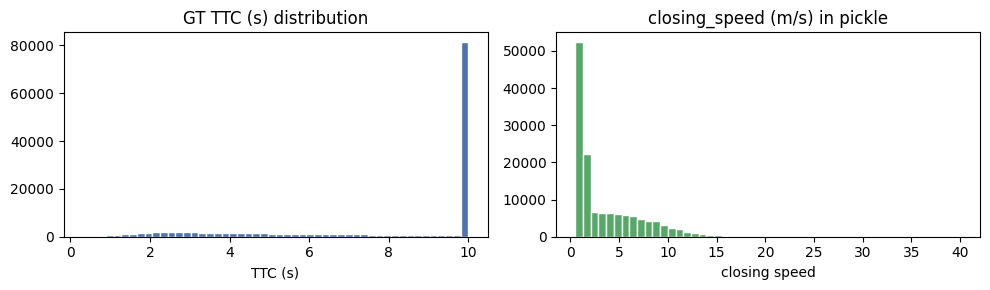

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

def load_ttc_payload(path: str):
    with open(path, "rb") as f:
        p = pickle.load(f)
    labels = p["labels"] if isinstance(p, dict) and "labels" in p else p
    meta = p.get("metadata", {}) if isinstance(p, dict) else {}
    return labels, meta, p

labels, meta, raw = load_ttc_payload(TTC_PKL)
n = len(labels)
ttc_vals = np.array([float(v["ttc"]) for v in labels.values()], dtype=np.float64)
cl_sp = None
if labels and "closing_speed" in next(iter(labels.values())):
    cl_sp = np.array([float(v["closing_speed"]) for v in labels.values()], dtype=np.float64)

print("n annotation labels:", n)
print("metadata (subset):", {k: meta[k] for k in list(meta.keys())[:12] if k in meta})
if meta:
    print("  ttc cap / min closing (if in metadata):", meta.get("ttc_cap_s"), meta.get("min_closing_speed_m_s"))
print("TTC  min/median/max:", float(np.min(ttc_vals)), float(np.median(ttc_vals)), float(np.max(ttc_vals)))
near_cap = np.sum(ttc_vals >= 9.5)
print("fraction of labels with TTC >= 9.5 s (near 10s cap):", float(near_cap) / n)

fig, ax = plt.subplots(1, 2 if cl_sp is not None else 1, figsize=(10, 3))
if cl_sp is None:
    ax = [ax]
ax[0].hist(ttc_vals, bins=50, color="#4C72B0", edgecolor="white")
ax[0].set_title("GT TTC (s) distribution")
ax[0].set_xlabel("TTC (s)")
if cl_sp is not None:
    ax[1].hist(cl_sp, bins=50, color="#55A868", edgecolor="white")
    ax[1].set_title("closing_speed (m/s) in pickle")
    ax[1].set_xlabel("closing speed")
plt.tight_layout()
plt.show()


## 2) Annotation token coverage in the TTC pickle


In [3]:
from pathlib import Path
import numpy as np

try:
    from nuscenes.nuscenes import NuScenes
except ImportError as e:
    print("Install nuscenes-devkit to run this cell:", e)
    NuScenes = None

if "labels" not in globals():
    import pickle as _p
    with open(TTC_PKL, "rb") as f:
        _raw = _p.load(f)
    labels = _raw["labels"] if isinstance(_raw, dict) and "labels" in _raw else _raw

N_SAMPLE_CAP = 400  # raise for a heavier scan
if NuScenes is not None and Path(NUSCENES_ROOT).is_dir():
    nusc = NuScenes(version=NUSCENES_VER, dataroot=str(NUSCENES_ROOT), verbose=False)
    n_ann = 0
    in_pkl = 0
    finite_ttc = 0
    for si, sample in enumerate(nusc.sample):
        if si >= N_SAMPLE_CAP:
            break
        for at in sample["anns"]:
            n_ann += 1
            if at in labels:
                in_pkl += 1
                t = labels[at].get("ttc", float("nan"))
                if t == t:  # finite
                    finite_ttc += 1
    print(f"Scanned first {N_SAMPLE_CAP} keyframes, annotation rows: {n_ann}")
    print("  ann tokens with a TTC key in the pickle: ", in_pkl, f"  ({100*in_pkl/max(1,n_ann):.1f}%)")
    print("  with finite ttc: ", finite_ttc)
    print("(A low in-pickle rate is often expected: many anns are skipped at label time.)")
else:
    print("Skip: need nuscenes-devkit and NUSCENES_ROOT.")


Scanned first 400 keyframes, annotation rows: 12526
  ann tokens with a TTC key in the pickle:  1113   (8.9%)
  with finite ttc:  1113
(A low in-pickle rate is often expected: many anns are skipped at label time.)


## 3) Tiered `loss_ttc` weights

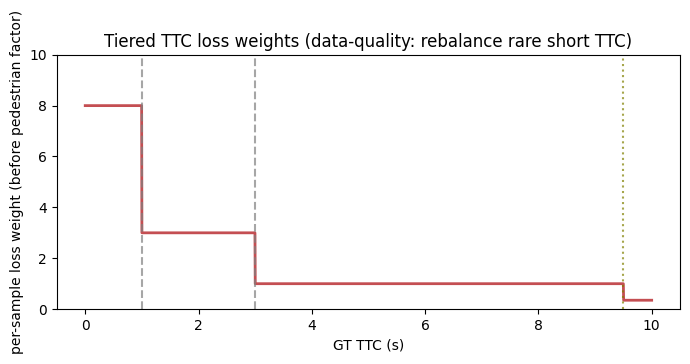

Config snapshot: {'TTC_LOW_THRESH_S': 3.0, 'TTC_LOW_WEIGHT': 3.0, 'TTC_CRIT_THRESH_S': 1.0, 'TTC_CRIT_WEIGHT': 8.0, 'TTC_CAP_THRESH_S': 9.5, 'TTC_CAP_WEIGHT': 0.35}
mean weight on labeled data (v2 params above): 0.8870245287138802   std: 1.015370030249266


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# These configs match the config I use in my actual runs
TTC_LOW_THRESH_S = 3.0
TTC_LOW_WEIGHT = 3.0
TTC_CRIT_THRESH_S = 1.0
TTC_CRIT_WEIGHT = 8.0
TTC_CAP_THRESH_S = 9.5
TTC_CAP_WEIGHT = 0.35
TTC_PEDESTRIAN_WEIGHT = 1.5
TTC_PEDESTRIAN_CLASS_IDX = 8

def ttc_gt_weights(
    tgt: np.ndarray,
    ttc_low_thresh_s: float,
    ttc_low_weight: float,
    ttc_crit_thresh_s: float,
    ttc_crit_weight: float,
    ttc_cap_thresh_s: float,
    ttc_cap_weight: float,
) -> np.ndarray:
    t = np.asarray(tgt, dtype=np.float64)
    w = np.ones_like(t)
    lt, lw = ttc_low_thresh_s, ttc_low_weight
    crit, cw = ttc_crit_thresh_s, ttc_crit_weight
    if crit > 0.0 and crit < lt:
        w = np.where(t < crit, cw, w)
        w = np.where((t >= crit) & (t < lt), lw, w)
    else:
        w = np.where(t < lt, lw, w)
    if ttc_cap_thresh_s and ttc_cap_thresh_s > 0:
        w = w * np.where(t >= ttc_cap_thresh_s, ttc_cap_weight, 1.0)
    return w

x = np.linspace(0, 10, 2000)
w = ttc_gt_weights(
    x, TTC_LOW_THRESH_S, TTC_LOW_WEIGHT,
    TTC_CRIT_THRESH_S, TTC_CRIT_WEIGHT,
    TTC_CAP_THRESH_S, TTC_CAP_WEIGHT,
)
plt.figure(figsize=(7, 3.5))
plt.plot(x, w, color="#C44E52", lw=2)
plt.axvline(TTC_CRIT_THRESH_S, color="gray", ls="--", alpha=0.7)
plt.axvline(TTC_LOW_THRESH_S, color="gray", ls="--", alpha=0.7)
if TTC_CAP_THRESH_S > 0:
    plt.axvline(TTC_CAP_THRESH_S, color="olive", ls=":", alpha=0.7)
plt.xlabel("GT TTC (s)")
plt.ylabel("per-sample loss weight (before pedestrian factor)")
plt.title("Tiered TTC loss weights (data-quality: rebalance rare short TTC)")
plt.ylim(0, max(10, float(w.max()) * 1.05))
plt.tight_layout()
plt.show()
print("Config snapshot:", {k: v for k, v in zip(
    ["TTC_LOW_THRESH_S","TTC_LOW_WEIGHT","TTC_CRIT_THRESH_S","TTC_CRIT_WEIGHT","TTC_CAP_THRESH_S","TTC_CAP_WEIGHT"],
    [TTC_LOW_THRESH_S, TTC_LOW_WEIGHT, TTC_CRIT_THRESH_S, TTC_CRIT_WEIGHT, TTC_CAP_THRESH_S, TTC_CAP_WEIGHT],
)})

# Compare mean weight you would put on a random TTC if GT came from the pickle
_ttc = globals().get("ttc_vals")
if _ttc is not None and getattr(_ttc, "size", 0) > 0:
    w_on_data = ttc_gt_weights(
        _ttc, TTC_LOW_THRESH_S, TTC_LOW_WEIGHT,
        TTC_CRIT_THRESH_S, TTC_CRIT_WEIGHT,
        TTC_CAP_THRESH_S, TTC_CAP_WEIGHT,
    )
    print("mean weight on labeled data (v2 params above):", float(w_on_data.mean()), "  std:", float(w_on_data.std()))
